### This model was built for Powei Microfinance Bank, after a recent mass churn of customers to see if more customers are likely to churn.

In [268]:
#Importation of the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

In [269]:
df = pd.read_csv('bank_customer_churn.csv')

In [270]:
df

,CustomerID,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
0,CUST00001,52.0,Male,67.0,55032.0,1.0,1.0,0.0,47462.0,0.0,4.0,0
1,CUST00002,NaN,Female,46.0,51902.0,2.0,0.0,1.0,137924.0,0.0,3.0,0
2,CUST00003,38.0,Female,30.0,106468.0,1.0,0.0,0.0,79385.0,0.0,5.0,0
3,CUST00004,NaN,Female,31.0,46640.0,1.0,1.0,1.0,67781.0,0.0,4.0,0
4,CUST00005,45.0,Male,31.0,137052.0,1.0,1.0,1.0,122601.0,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST00496,24.0,Female,NaN,71841.0,1.0,1.0,0.0,137288.0,0.0,3.0,0
496,CUST00497,26.0,Female,85.0,55620.0,2.0,1.0,0.0,132202.0,0.0,5.0,0
497,CUST00498,37.0,Female,60.0,101396.0,1.0,1.0,0.0,108634.0,0.0,3.0,0
498,CUST00499,39.0,Male,51.0,79169.0,1.0,1.0,0.0,176583.0,0.0,5.0,0


### Running my EDA.

In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          500 non-null    str    
 1   Age                 468 non-null    float64
 2   Gender              474 non-null    str    
 3   Tenure_Months       463 non-null    float64
 4   Balance             466 non-null    float64
 5   NumOfProducts       471 non-null    float64
 6   HasCrCard           474 non-null    float64
 7   IsActiveMember      477 non-null    float64
 8   EstimatedSalary     459 non-null    float64
 9   Complains           489 non-null    float64
 10  Satisfaction_Score  472 non-null    float64
 11  Churn               500 non-null    int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 47.0 KB


In [272]:
df.describe()

,Age,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
count,468.000000,463.000000,466.000000,471.000000,474.000000,477.000000,459.000000,489.000000,472.000000,500.000000
mean,38.158120,44.863931,71983.431330,1.522293,0.696203,0.566038,107902.893246,0.276074,3.525424,0.250000
std,9.316502,26.323677,46714.399058,0.819335,0.460382,0.496140,42977.467918,0.447511,1.095925,0.433446
min,18.000000,1.000000,53.000000,1.000000,0.000000,0.000000,31782.000000,0.000000,1.000000,0.000000
25%,30.750000,23.000000,31053.500000,1.000000,0.000000,0.000000,72993.500000,0.000000,3.000000,0.000000
50%,38.000000,41.000000,64751.000000,1.000000,1.000000,1.000000,108014.000000,0.000000,3.000000,0.000000
75%,46.000000,69.000000,106858.750000,2.000000,1.000000,1.000000,145174.500000,1.000000,4.000000,0.250000
max,57.000000,95.000000,197316.000000,4.000000,1.000000,1.000000,179621.000000,1.000000,5.000000,1.000000


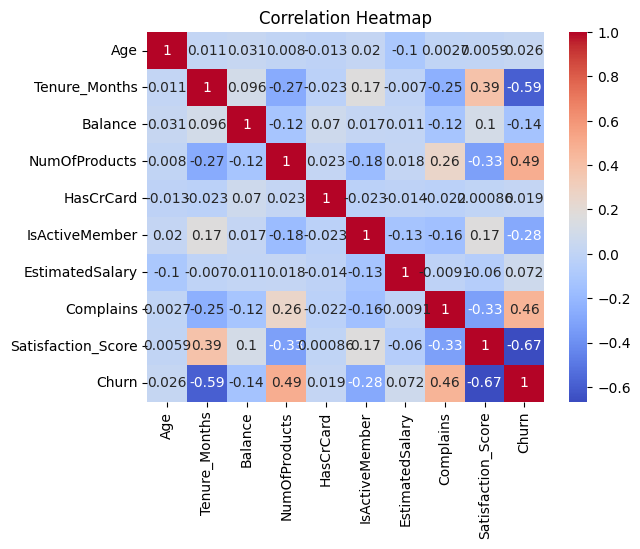

In [273]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

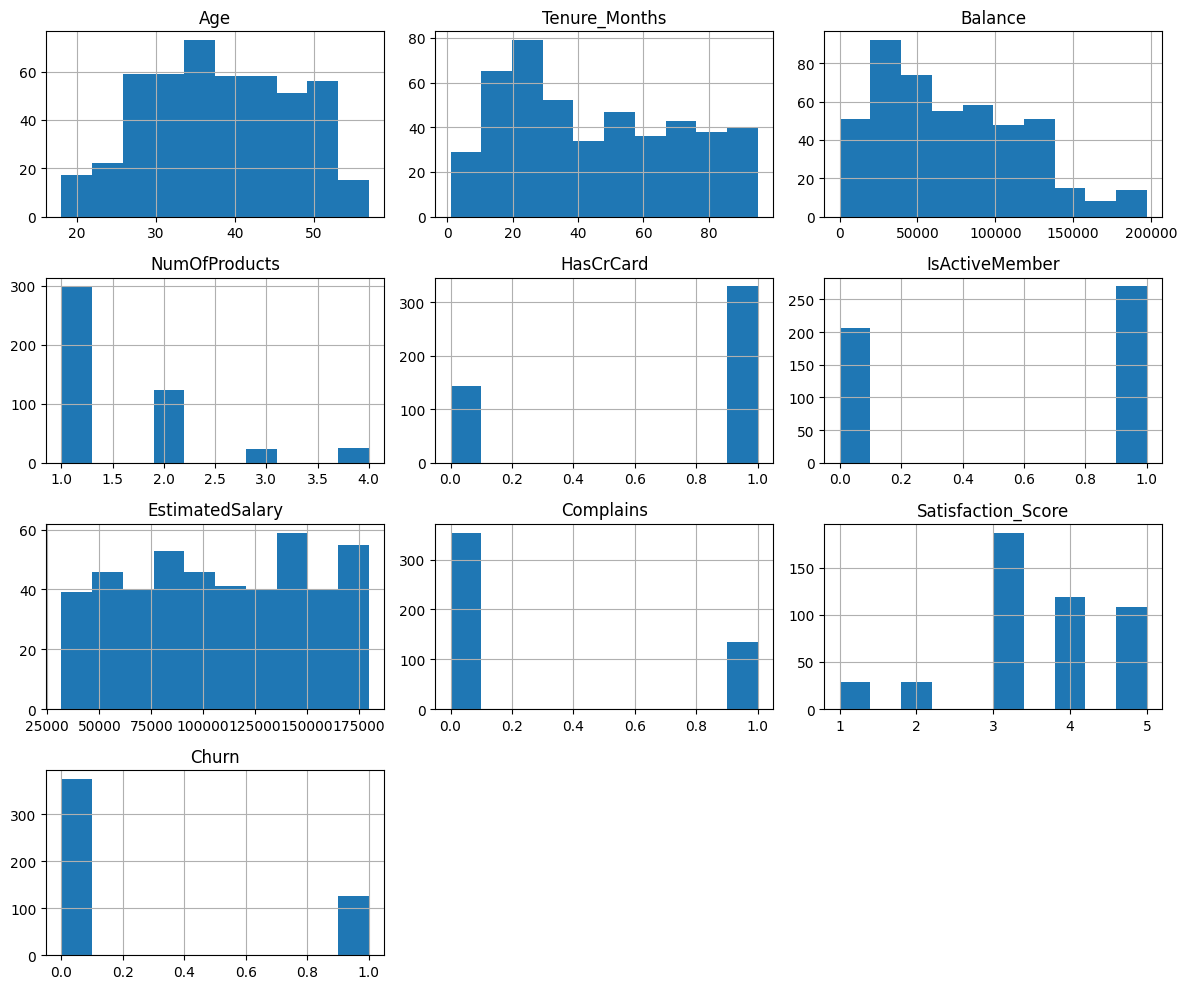

In [274]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

### Handling my missing data

In [275]:
df['Gender'] = df['Gender'].astype(str).replace('nan', np.nan)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])



In [276]:
# This should return 0 if it worked
print(df['Gender'].isnull().sum()) 

0


In [277]:
df['Tenure_Months'] = df['Tenure_Months'].fillna(df['Tenure_Months'].mean())

In [278]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].mean())

In [279]:
df['Complains'] = df['Complains'].fillna(df['Complains'].mean())

In [280]:
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].mean())

In [281]:
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mean())

In [282]:
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())

In [283]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [284]:
df['NumOfProducts'] = df['NumOfProducts'].fillna(df['NumOfProducts'].mean())

In [285]:
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mean())

In [286]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          500 non-null    str    
 1   Age                 500 non-null    float64
 2   Gender              500 non-null    str    
 3   Tenure_Months       500 non-null    float64
 4   Balance             500 non-null    float64
 5   NumOfProducts       500 non-null    float64
 6   HasCrCard           500 non-null    float64
 7   IsActiveMember      500 non-null    float64
 8   EstimatedSalary     500 non-null    float64
 9   Complains           500 non-null    float64
 10  Satisfaction_Score  500 non-null    float64
 11  Churn               500 non-null    int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 47.0 KB


### Taking care of categorical data

In [287]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

### Choosing my features and assigning them to variables of x and y

In [288]:
x = df.iloc[:, [3, 4, 5, 7, 9, 10] ].values
y = df.iloc[:, -1].values
print(x)
print(y)

[[6.70000e+01 5.50320e+04 1.00000e+00 0.00000e+00 0.00000e+00 4.00000e+00]
 [4.60000e+01 5.19020e+04 2.00000e+00 1.00000e+00 0.00000e+00 3.00000e+00]
 [3.00000e+01 1.06468e+05 1.00000e+00 0.00000e+00 0.00000e+00 5.00000e+00]
 ...
 [6.00000e+01 1.01396e+05 1.00000e+00 0.00000e+00 0.00000e+00 3.00000e+00]
 [5.10000e+01 7.91690e+04 1.00000e+00 0.00000e+00 0.00000e+00 5.00000e+00]
 [7.60000e+01 8.49240e+04 2.00000e+00 1.00000e+00 0.00000e+00 3.00000e+00]]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0
 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0
 0 1 0 1 0 1 0 0 0 

### Splitting my dataset

In [289]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

### Creating my model

In [290]:
Powei = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=24)
Powei.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluating my model

In [291]:
y_pred = Powei.predict(x_test)

In [292]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", Powei.score(x_test, y_test))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        75
           1       1.00      0.92      0.96        25

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100

[[75  0]
 [ 2 23]]
Accuracy: 0.98


### Feature importance

In [293]:
features = ['Tenure_Months', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Complains', 'Satisfaction_Score']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': Powei.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

              Feature  Importance
0       Tenure_Months    0.295722
5  Satisfaction_Score    0.290998
1             Balance    0.262876
2       NumOfProducts    0.076734
4           Complains    0.056589
3      IsActiveMember    0.017081


### Visualizing my first tree

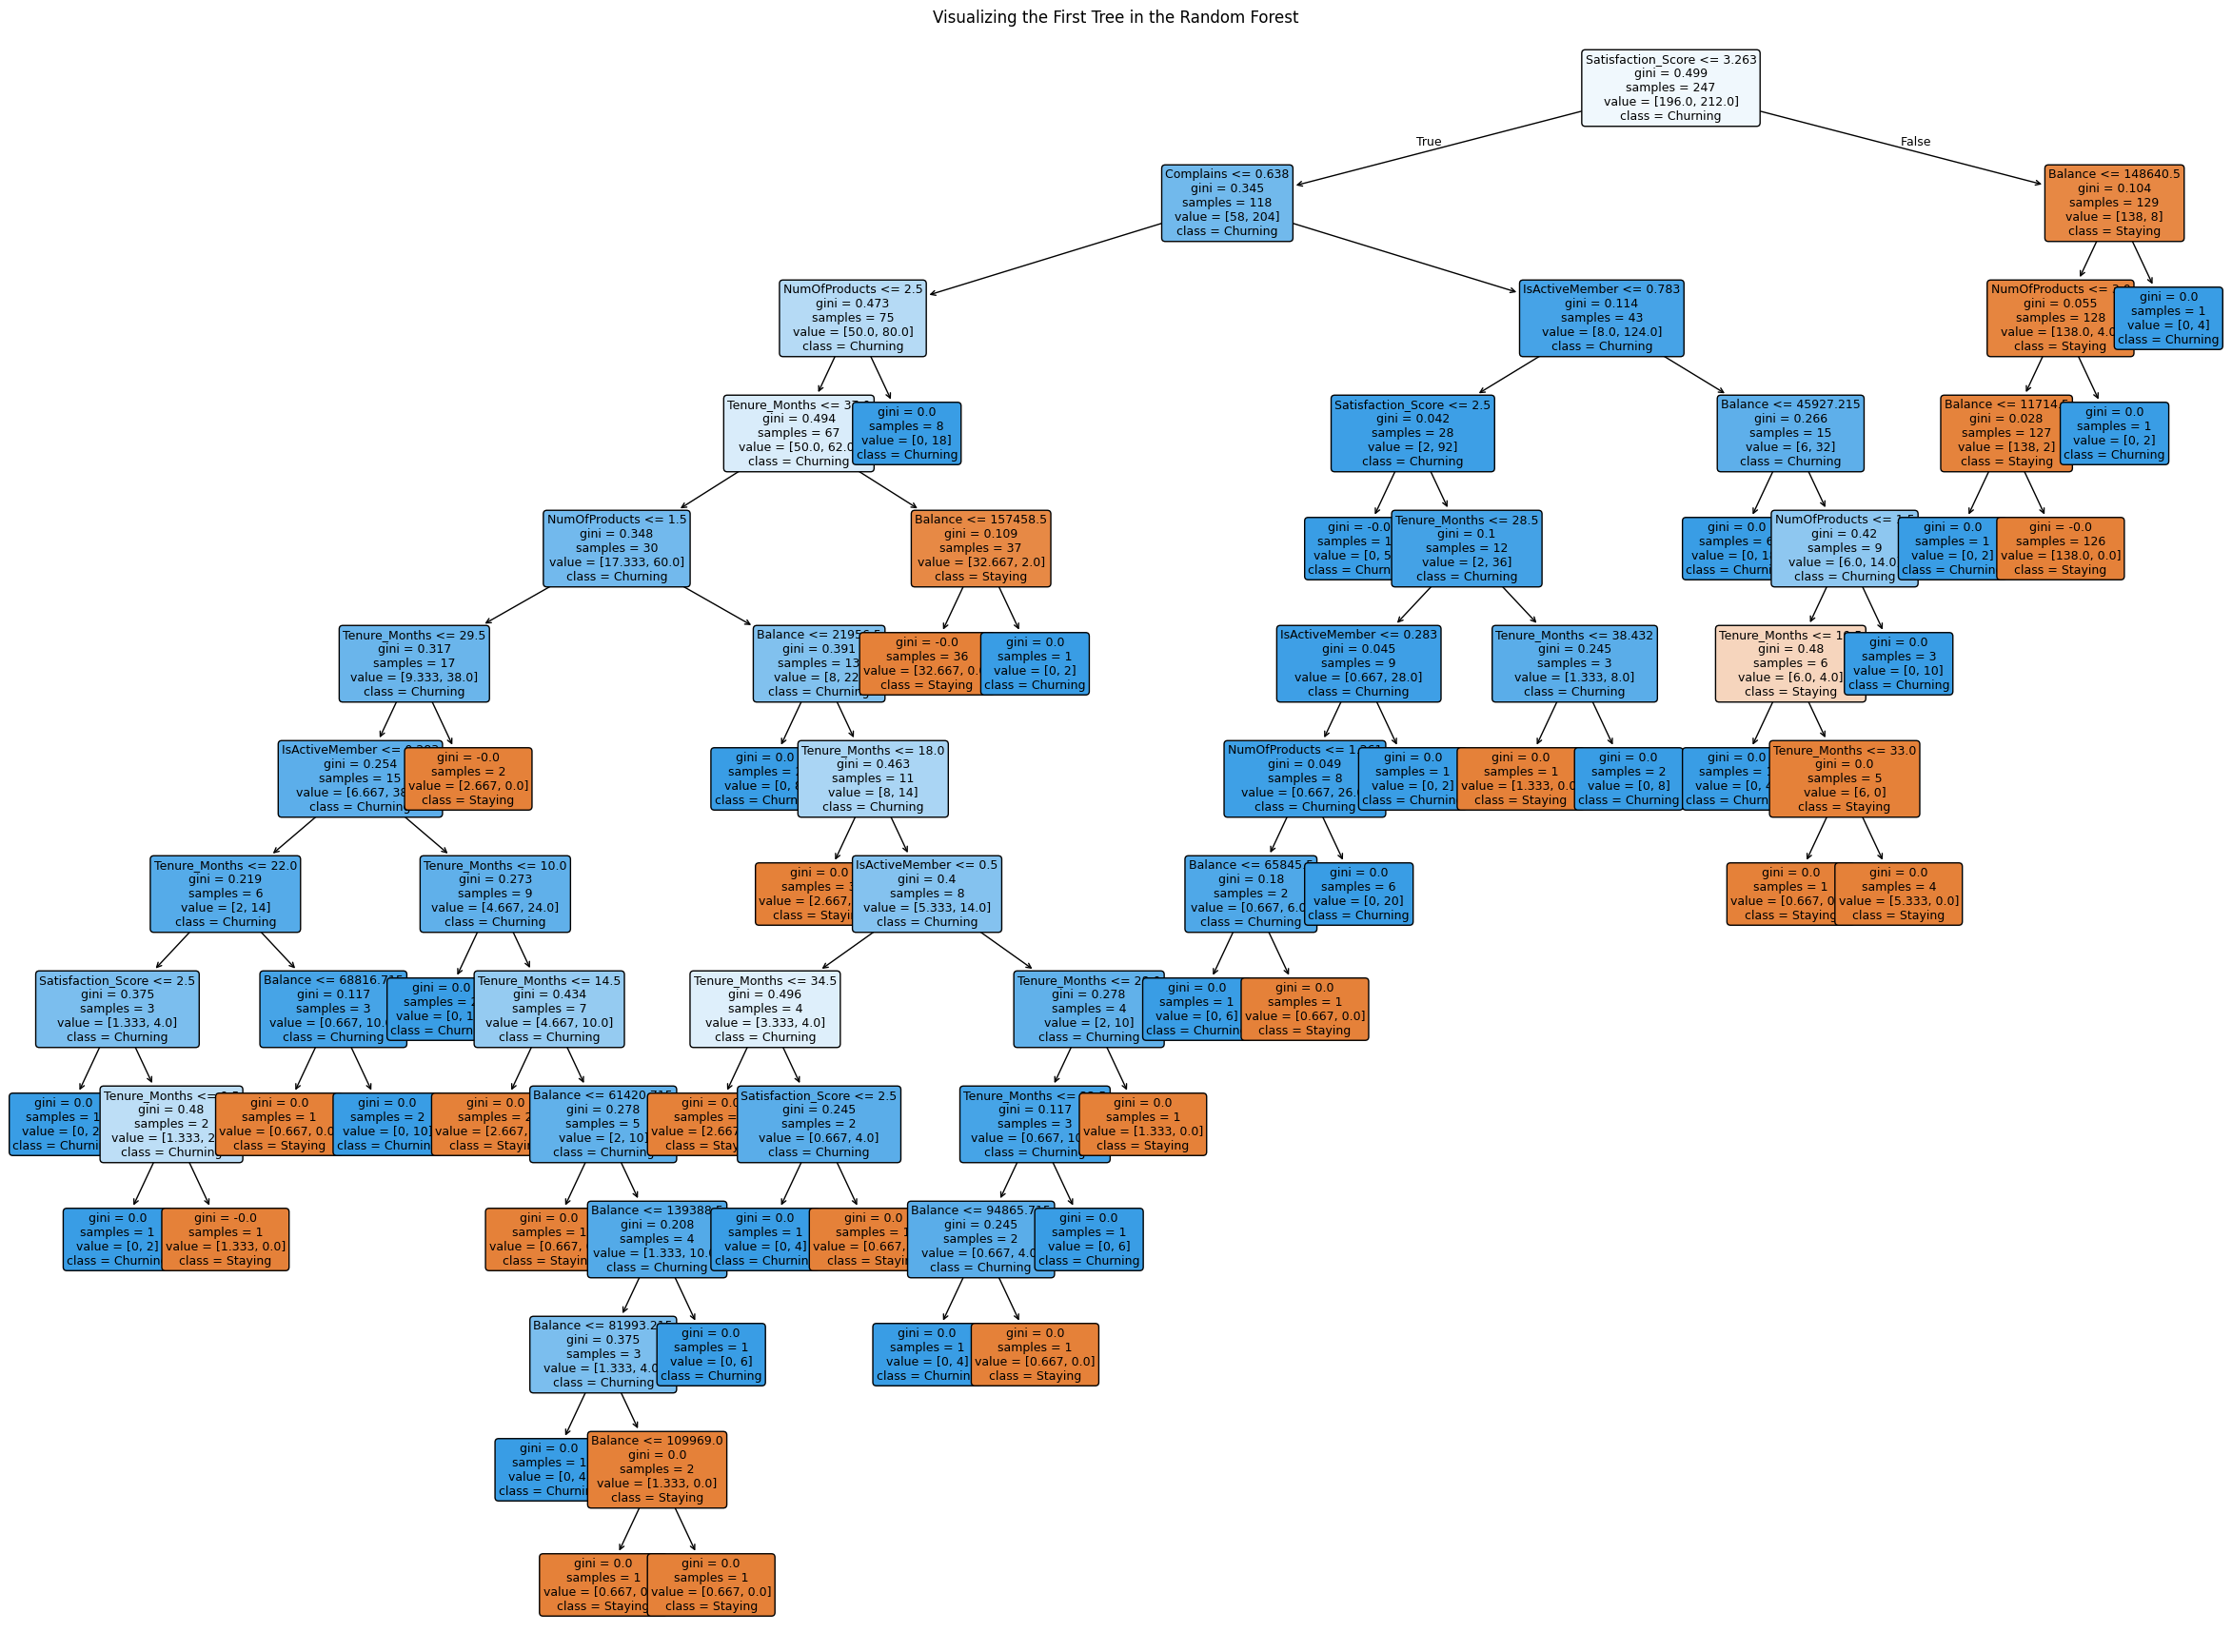

In [294]:
features = ['Tenure_Months', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Complains', 'Satisfaction_Score']
tree_to_plot = Powei.estimators_[0] 
plt.figure(figsize=(30,22))
plot_tree(tree_to_plot, 
          feature_names=features, 
          class_names=['Staying', 'Churning'], 
          filled=True, 
          rounded=True,
          fontsize=9)
plt.title("Visualizing the First Tree in the Random Forest")
plt.savefig('Powei_Microfinance_Bank.png')
plt.show()

### Report documentation

This model was built on behalf of Powei Microfinance Bank using data of recent churning by customers. The bank wanted to put a stop to this trend. The data contained 12 columns and 500 rows. The goal was to build a model that would be able to predict if customer will stay or churn.

After carrying out my EDA, I discovered some missing data and quickly fixed them. From my EDA, I quickly discovered that most of the proposed features such as Age, Gender, Estimated Salary and Has Credit Card had zero correlation with my proposed target 'Churn'. Despite some of them having a good variance, I decided to leave them out because of the 0 correlation. Balance had a low correlation but had to be add because it's variance level made a good case for it, and at the end, it showed to be an excellent decision, because it turned out to be an important feature with 0.26 importance level.

The feature importance list can be seen below;
    Feature                             Importance
0   Tenure_Months                       0.295722
1   Satisfaction_Score                  0.290998
2   Balance                             0.262876
3   NumOfProducts                       0.076734
4   Complains                           0.056589
5   IsActiveMember                      0.017081

The model should be perfect for this job because it has a accurate score of 98% with an excellent precision, recall and f1 score. The features used were Tenure_Months, Balance, Number Of Products, Is an Active Member, Complains,and Satisfaction_Score. 
From the importance list above, the following features; Tenure_Months, Satisfaction_Score, Balance, Number Of Products are key to predicting any future customer churning activity.

### Recommendation

To reduce customer churn, I recommend that Powei Microfinance Bank should focus on strengthening early customer relationships, and actively monitor customer satisfaction. 
Customers with shorter tenure, lower satisfaction scores, and low balances are more likely to churn easily. By offering welcome programs, resolving complaints quickly, and promoting additional products or savings incentives, the bank can make customers feel valued and invested.